# VanillaAE Analysis
Train: 2013–2023 | Test: 2024–2026 | K=5 latent factors

Run `python scripts/run_8ae_5k_comparison.py --archs VanillaAE --factors 5 --output results/vanilla_ae_k5` before opening this notebook.

In [19]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import seaborn as sns

FACTORS = next(
    p / 'vanilla_ae_k5' / 'factors'
    for p in [Path('.').resolve(), Path('.').resolve().parent]
    if (p / 'vanilla_ae_k5' / 'factors' / 'VanillaAE_train_factors.csv').exists()
)
ERRORS = next(
    p / 'vanilla_ae_k5' / 'errors'
    for p in [Path('.').resolve(), Path('.').resolve().parent]
    if (p / 'vanilla_ae_k5' / 'errors' / 'VanillaAE_train_recon_error.csv').exists()
)

ARCH = 'VanillaAE'

assert (FACTORS / f'{ARCH}_train_factors.csv').exists(), (
    'No VanillaAE data found. Run first:\n'
    '  python scripts/run_8ae_5k_comparison.py --archs VanillaAE --factors 5 --output results/vanilla_ae_k5'
)

SECTOR_MAP = {
    'Brent': 'Energy', 'WTI': 'Energy', 'NaturalGas': 'Energy', 'Gasoline': 'Energy',
    'Diesel': 'Energy', 'HeatingOil': 'Energy', 'ThermalCoal': 'Energy', 'Methanol': 'Energy',
    'Gold': 'Metals', 'Silver': 'Metals', 'Copper': 'Metals', 'Aluminium': 'Metals',
    'Nickel': 'Metals', 'Zinc': 'Metals', 'Platinum': 'Metals', 'HRCSteel': 'Metals',
    'SGXIronOre': 'Metals', 'Lithium': 'Metals',
    'Coffee': 'Agriculture', 'Corn': 'Agriculture', 'Cotton': 'Agriculture',
    'LeanHogs': 'Agriculture', 'LiveCattle': 'Agriculture', 'Sugar': 'Agriculture',
    'Soybeans': 'Agriculture', 'SoybeanOil': 'Agriculture', 'HRWWheat': 'Agriculture',
}
SECTOR_ORDER = ['Energy', 'Metals', 'Agriculture']
COMMODITIES_ORDERED = sorted(
    SECTOR_MAP, key=lambda c: (SECTOR_ORDER.index(SECTOR_MAP[c]), list(SECTOR_MAP).index(c))
)

train_err     = pd.read_csv(ERRORS  / f'{ARCH}_train_recon_error.csv', index_col=0, parse_dates=True)
test_err      = pd.read_csv(ERRORS  / f'{ARCH}_test_recon_error.csv',  index_col=0, parse_dates=True)
train_factors = pd.read_csv(FACTORS / f'{ARCH}_train_factors.csv',     index_col=0, parse_dates=True)
test_factors  = pd.read_csv(FACTORS / f'{ARCH}_test_factors.csv',      index_col=0, parse_dates=True)

train_mse_per_com = (train_err ** 2).mean()
test_mse_per_com  = (test_err  ** 2).mean()
train_mse = float((train_err.to_numpy() ** 2).mean())
test_mse  = float((test_err.to_numpy()  ** 2).mean())

print(f'Train MSE: {train_mse:.5f}    Test MSE: {test_mse:.5f}    Gap: {test_mse - train_mse:.5f}')

Train MSE: 0.59909    Test MSE: 0.67151    Gap: 0.07242


## Summary Table

In [20]:
summary = pd.DataFrame({
    'MSE':  [train_mse, test_mse],
    'RMSE': [np.sqrt(train_mse), np.sqrt(test_mse)],
    'R2':   [1 - train_mse, 1 - test_mse],
    'generalisation_gap': [0.0, test_mse - train_mse],
}, index=['Train (2013–2023)', 'Test (2024–2026)'])
display(summary.round(5))

,MSE,RMSE,R2,generalisation_gap
Train (2013–2023),0.59909,0.77401,0.40091,0.00000
Test (2024–2026),0.67151,0.81945,0.32849,0.07242


## 1. Per-Commodity Reconstruction MSE

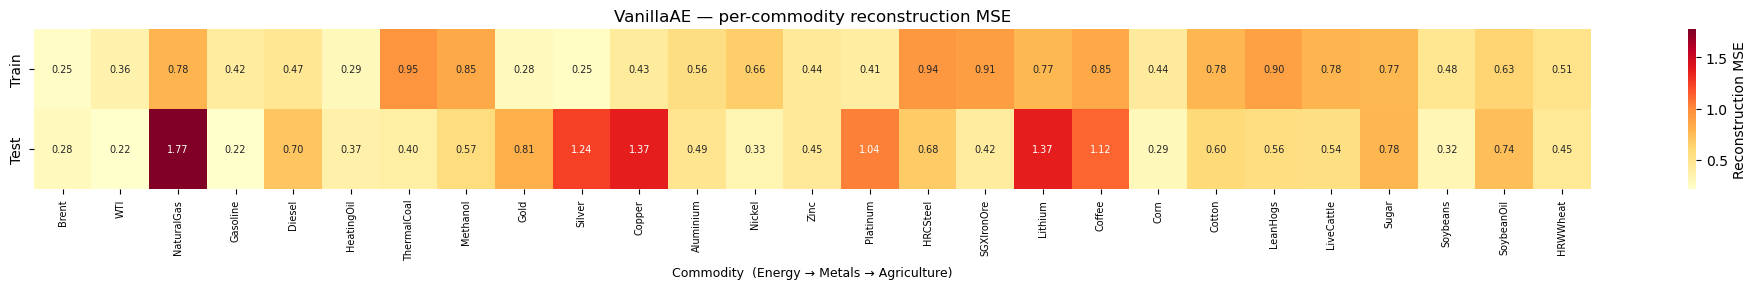

In [21]:
mse_df = pd.DataFrame({
    'Train': train_mse_per_com[COMMODITIES_ORDERED],
    'Test':  test_mse_per_com[COMMODITIES_ORDERED],
}).T

fig, ax = plt.subplots(figsize=(20, 3))
sns.heatmap(
    mse_df, cmap='YlOrRd', annot=True, fmt='.2f',
    annot_kws={'size': 7}, cbar_kws={'label': 'Reconstruction MSE'}, ax=ax,
)
ax.set_title('VanillaAE — per-commodity reconstruction MSE')
ax.set_xlabel('Commodity  (Energy → Metals → Agriculture)', fontsize=9)
ax.tick_params(axis='x', rotation=90, labelsize=7)
fig.tight_layout()
plt.show()

## 2. R² per Commodity

R² = 1 − MSE (valid because input is z-scored, so baseline variance = 1 per commodity).

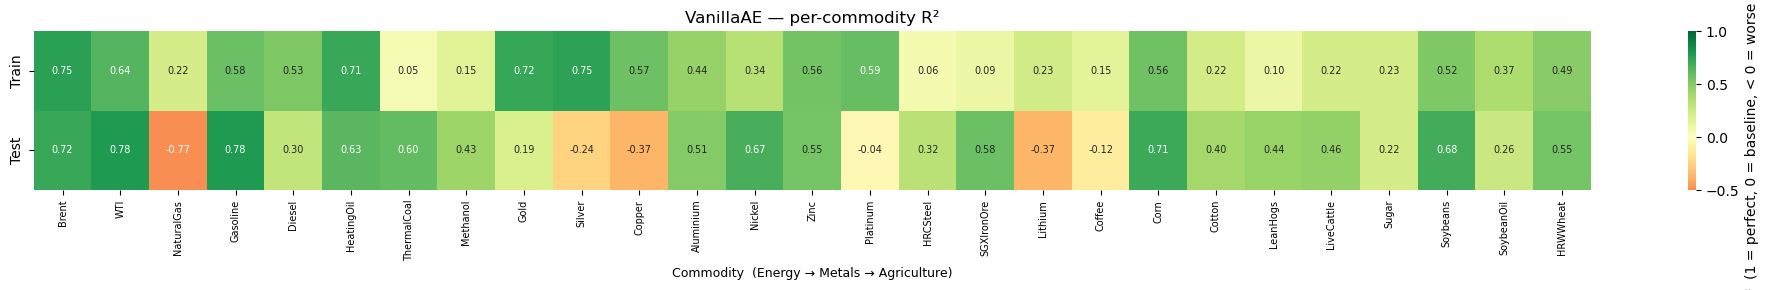

In [22]:
r2_df = pd.DataFrame({
    'Train': 1 - train_mse_per_com[COMMODITIES_ORDERED],
    'Test':  1 - test_mse_per_com[COMMODITIES_ORDERED],
}).T

fig, ax = plt.subplots(figsize=(20, 3))
sns.heatmap(
    r2_df, cmap='RdYlGn', center=0, vmin=-0.5, vmax=1.0,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cbar_kws={'label': 'R²  (1 = perfect, 0 = baseline, < 0 = worse than mean)'},
    ax=ax,
)
ax.set_title('VanillaAE — per-commodity R²')
ax.set_xlabel('Commodity  (Energy → Metals → Agriculture)', fontsize=9)
ax.tick_params(axis='x', rotation=90, labelsize=7)
fig.tight_layout()
plt.show()

## 3. Per-Sector Metrics

In [23]:
for label, mse_ser in [('Train (2013–2023)', train_mse_per_com), ('Test (2024–2026)', test_mse_per_com)]:
    rows = []
    for sector in SECTOR_ORDER:
        coms = [c for c in COMMODITIES_ORDERED if SECTOR_MAP[c] == sector]
        mse  = float(mse_ser[coms].mean())
        rows.append({'sector': sector, 'MSE': mse, 'RMSE': np.sqrt(mse), 'R2': 1 - mse})
    overall = float(mse_ser.mean())
    rows.append({'sector': 'ALL', 'MSE': overall, 'RMSE': np.sqrt(overall), 'R2': 1 - overall})
    print(f'\n{label}')
    display(pd.DataFrame(rows).set_index('sector').round(4))


Train (2013–2023)


,MSE,RMSE,R2
sector,,,
Energy,0.5467,0.7394,0.4533
Metals,0.5652,0.7518,0.4348
Agriculture,0.6832,0.8266,0.3168
ALL,0.5991,0.7740,0.4009



Test (2024–2026)


,MSE,RMSE,R2
sector,,,
Energy,0.5671,0.7531,0.4329
Metals,0.8191,0.9050,0.1809
Agriculture,0.6003,0.7748,0.3997
ALL,0.6715,0.8195,0.3285


## 4. Factor Variances

Low variance on a factor means the encoder has collapsed that dimension toward zero.

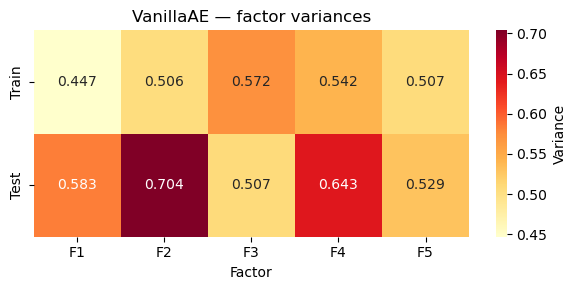

In [24]:
var_df = pd.DataFrame({'Train': train_factors.var(), 'Test': test_factors.var()})

fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(
    var_df.T, cmap='YlOrRd', annot=True, fmt='.3f',
    annot_kws={'size': 10}, ax=ax, cbar_kws={'label': 'Variance'},
)
ax.set_title('VanillaAE — factor variances')
ax.set_xlabel('Factor')
fig.tight_layout()
plt.show()

## 5. Active Factor Count

A factor is “active” if its variance exceeds 0.1.

In [25]:
THRESHOLD = 0.1
for split, fac in [('Train', train_factors), ('Test', test_factors)]:
    active = int((fac.var() > THRESHOLD).sum())
    print(f'{split}: {active}/{len(fac.columns)} factors active (variance > {THRESHOLD})')
    display(fac.var().rename('variance').to_frame().T.round(4))

Train: 5/5 factors active (variance > 0.1)


,F1,F2,F3,F4,F5
variance,0.4469,0.5058,0.5722,0.5419,0.5071


Test: 5/5 factors active (variance > 0.1)


,F1,F2,F3,F4,F5
variance,0.5833,0.7039,0.5073,0.6429,0.5295


## 6. Factor Time Series

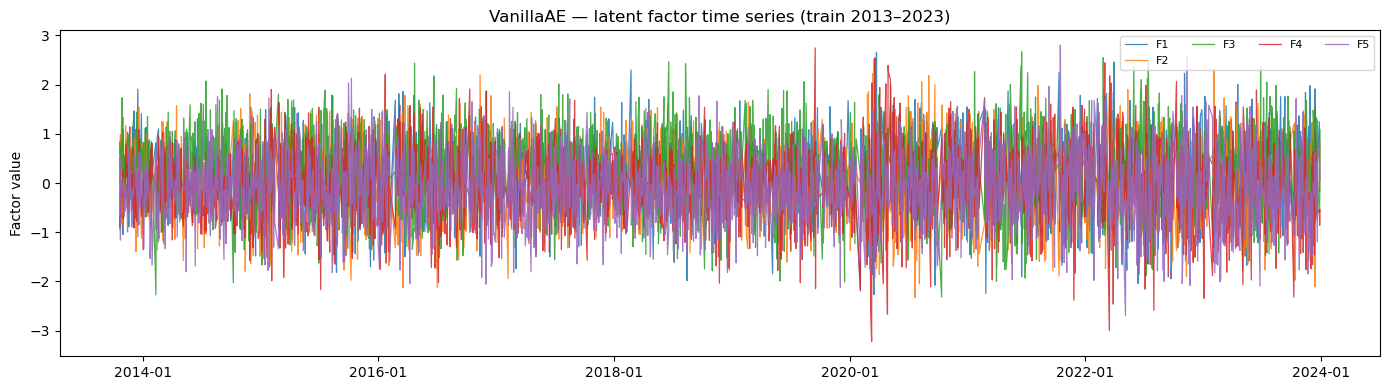

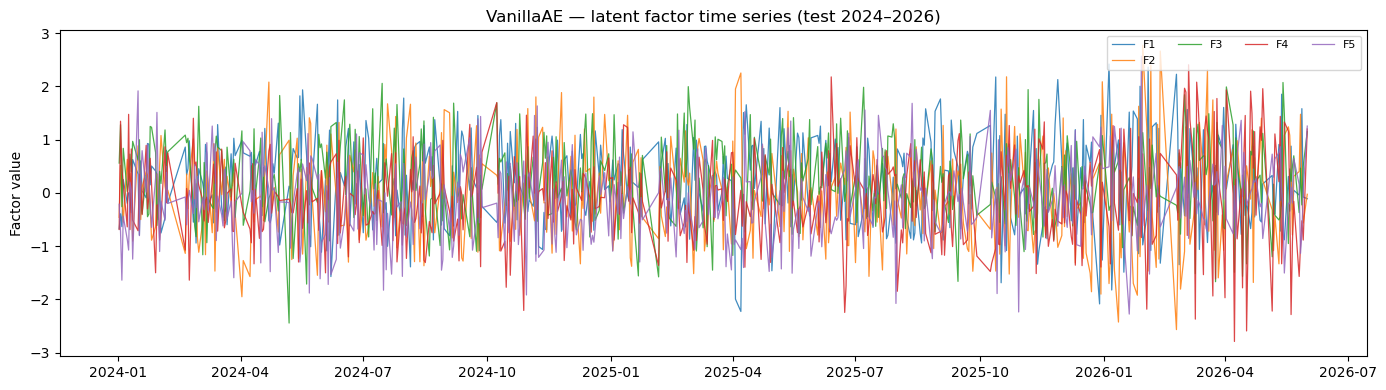

In [26]:
for split, fac in [('train', train_factors), ('test', test_factors)]:
    year_range = '2013–2023' if split == 'train' else '2024–2026'
    fig, ax = plt.subplots(figsize=(14, 4))
    for col in fac.columns:
        ax.plot(fac.index, fac[col], lw=0.9, alpha=0.85, label=col)
    ax.set_title(f'VanillaAE — latent factor time series ({split} {year_range})')
    ax.set_ylabel('Factor value')
    ax.legend(loc='upper right', fontsize=8, ncol=4)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.tight_layout()
    plt.show()

## 7. Factor Cross-Correlation Heatmap

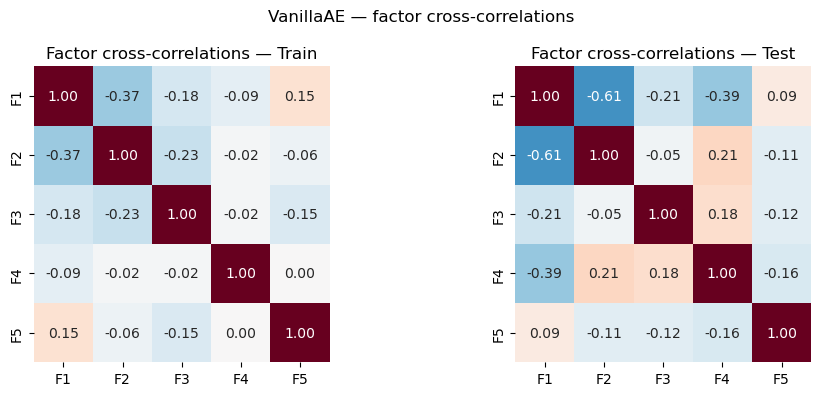

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (label, fac) in zip(axes, [('Train', train_factors), ('Test', test_factors)]):
    sns.heatmap(
        fac.corr(), ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        annot=True, fmt='.2f', annot_kws={'size': 10}, square=True, cbar=False,
    )
    ax.set_title(f'Factor cross-correlations — {label}')
fig.suptitle('VanillaAE — factor cross-correlations', fontsize=12)
fig.tight_layout()
plt.show()

## 8. Latent Factor Interpretation

Correlation between each latent factor and each commodity return — the autoencoder equivalent of PCA loadings.

In [28]:
returns_raw = pd.read_csv('../data/returns.csv', index_col=0, parse_dates=True)

def factor_commodity_corr(factors):
    rets = returns_raw.reindex(factors.index)[COMMODITIES_ORDERED]
    return pd.DataFrame(
        {col: factors.corrwith(rets[col]) for col in rets.columns},
        index=factors.columns,
    )

### 8a. Factor–Commodity Correlation Heatmaps (Train then Test)

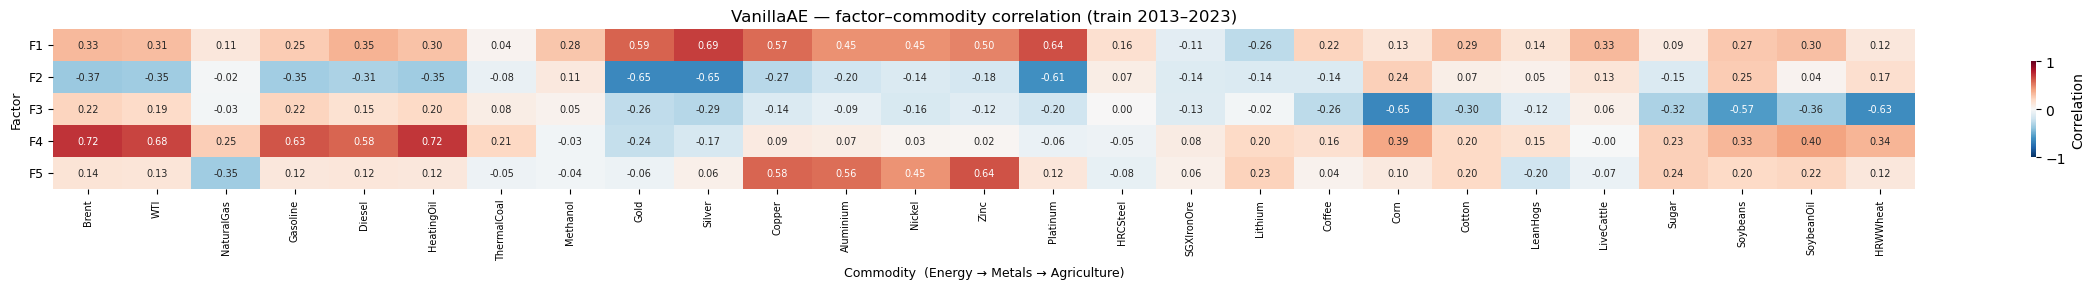

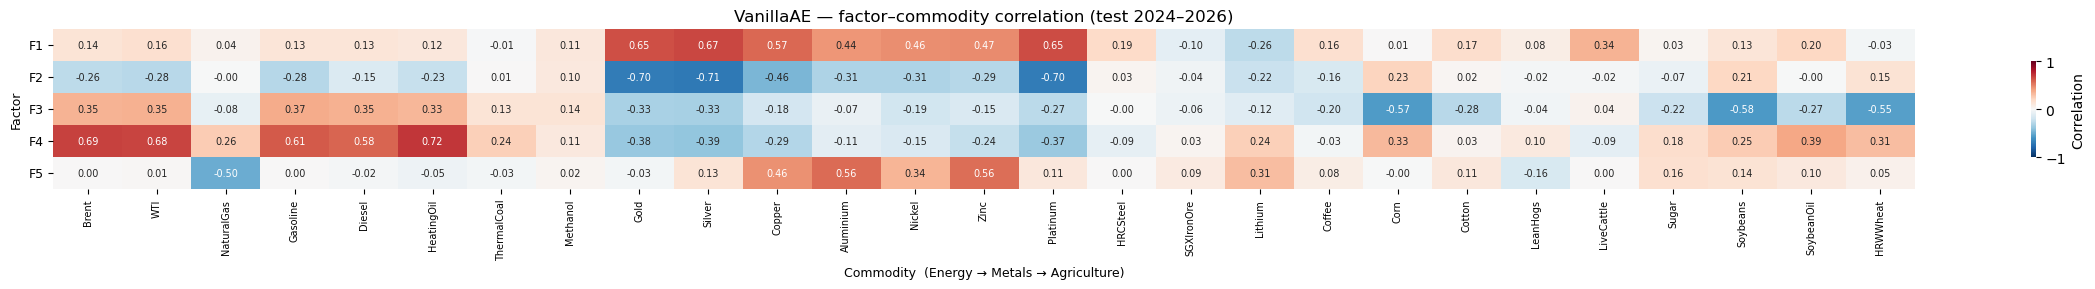

In [29]:
for split, fac in [('train', train_factors), ('test', test_factors)]:
    corr = factor_commodity_corr(fac)
    year = '2013–2023' if split == 'train' else '2024–2026'
    fig, ax = plt.subplots(figsize=(24, 3))
    sns.heatmap(
        corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        annot=True, fmt='.2f', annot_kws={'size': 7},
        xticklabels=corr.columns, yticklabels=corr.index, cbar=True,
        cbar_kws={'label': 'Correlation', 'shrink': 0.6},
    )
    ax.set_title(f'VanillaAE — factor–commodity correlation ({split} {year})', fontsize=12)
    ax.set_xlabel('Commodity  (Energy → Metals → Agriculture)', fontsize=9)
    ax.set_ylabel('Factor', fontsize=9)
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=9)
    fig.tight_layout()
    plt.show()

### 8b. Top Commodities per Factor (Train, by Absolute Correlation)

In [30]:
TOP_N = 5
corr = factor_commodity_corr(train_factors)
rows = []
for factor in corr.index:
    top = corr.loc[factor].abs().nlargest(TOP_N)
    for rank, (com, _) in enumerate(top.items(), 1):
        rows.append({
            'factor':      factor,
            'rank':        rank,
            'commodity':   com,
            'sector':      SECTOR_MAP[com],
            'correlation': round(corr.loc[factor, com], 3),
        })
display(pd.DataFrame(rows).set_index(['factor', 'rank']))

commodity       sector  correlation
factor rank                                      
F1     1         Silver       Metals        0.689
       2       Platinum       Metals        0.643
       3           Gold       Metals        0.591
       4         Copper       Metals        0.569
       5           Zinc       Metals        0.499
F2     1         Silver       Metals       -0.647
       2           Gold       Metals       -0.647
       3       Platinum       Metals       -0.612
       4          Brent       Energy       -0.370
       5            WTI       Energy       -0.353
F3     1           Corn  Agriculture       -0.654
       2       HRWWheat  Agriculture       -0.630
       3       Soybeans  Agriculture       -0.569
       4     SoybeanOil  Agriculture       -0.356
       5          Sugar  Agriculture       -0.316
F4     1          Brent       Energy        0.723
       2     HeatingOil       Energy        0.716
       3            WTI       Energy        0.678
       4       Gasoline       Energy        0.631
       5         Diesel       Energy        0.580
F5     1           Zinc       Metals        0.641
       2         Copper       Metals        0.580
       3      Aluminium       Metals        0.559
       4         Nickel       Metals        0.446
       5     NaturalGas       Energy       -0.354

### 8c. Factor–Sector Alignment (Mean |Correlation| per Sector)

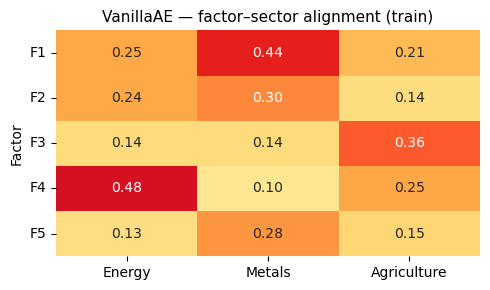

In [31]:
corr_train = factor_commodity_corr(train_factors)
alignment = pd.DataFrame({
    sector: corr_train[[c for c in COMMODITIES_ORDERED if SECTOR_MAP[c] == sector]].abs().mean(axis=1)
    for sector in SECTOR_ORDER
})

fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(
    alignment, ax=ax, cmap='YlOrRd', vmin=0, vmax=0.6,
    annot=True, fmt='.2f', annot_kws={'size': 10}, cbar=False,
)
ax.set_title('VanillaAE — factor–sector alignment (train)', fontsize=11)
ax.set_ylabel('Factor')
ax.tick_params(axis='y', rotation=0)
fig.tight_layout()
plt.show()

### 8d. Factor Autocorrelation — Temporal Persistence

Lag-1 (daily), lag-5 (weekly), lag-21 (monthly) autocorrelation per factor. High autocorrelation → slow macro regime signal. Near zero → fast noise.

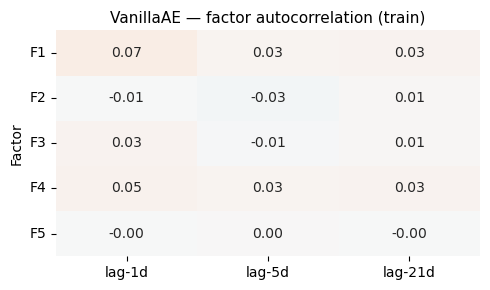

In [32]:
LAGS = [1, 5, 21]
acorr = pd.DataFrame(
    {f'lag-{lag}d': train_factors.apply(lambda col: col.autocorr(lag=lag)) for lag in LAGS}
)

fig, ax = plt.subplots(figsize=(5, 3))
sns.heatmap(
    acorr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 10}, cbar=False,
)
ax.set_title('VanillaAE — factor autocorrelation (train)', fontsize=11)
ax.set_ylabel('Factor')
ax.tick_params(axis='y', rotation=0)
fig.tight_layout()
plt.show()

### 8e. Rolling Factor–Commodity Correlation (Stability)

252-day rolling correlation between each factor and its highest-correlated commodity. Stable lines = consistent economic interpretation across time.

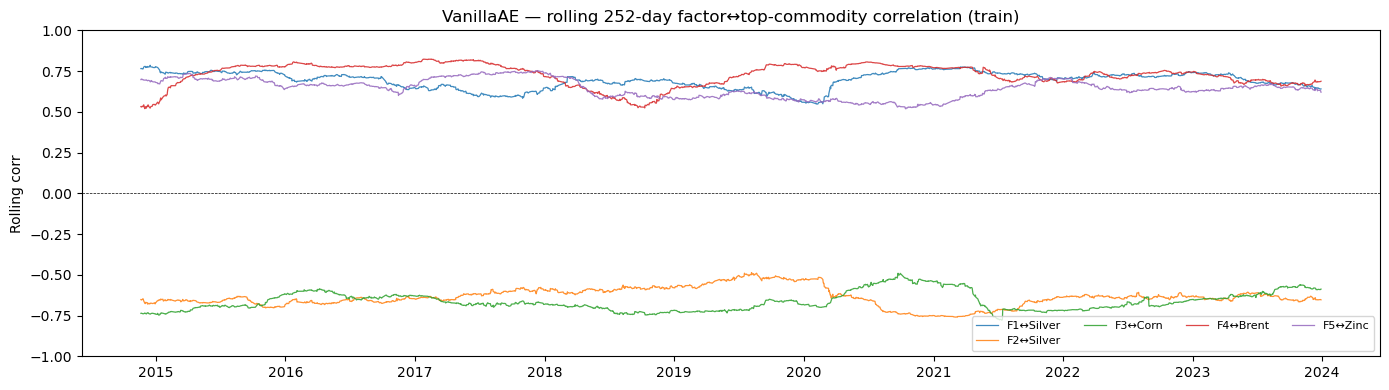

In [33]:
ROLL_WINDOW = 252
corr_full = factor_commodity_corr(train_factors)
rets = returns_raw.reindex(train_factors.index)

fig, ax = plt.subplots(figsize=(14, 4))
for factor in corr_full.index:
    top_com = corr_full.loc[factor].abs().idxmax()
    rolling = train_factors[factor].rolling(ROLL_WINDOW).corr(rets[top_com])
    ax.plot(rolling.index, rolling, lw=0.9, alpha=0.85, label=f'{factor}↔{top_com}')
ax.axhline(0, color='k', lw=0.5, ls='--')
ax.set_ylim(-1, 1)
ax.set_title(f'VanillaAE — rolling {ROLL_WINDOW}-day factor↔top-commodity correlation (train)')
ax.set_ylabel('Rolling corr')
ax.legend(loc='lower right', fontsize=8, ncol=4)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()

### 8f. Factor Behaviour Around Market Events

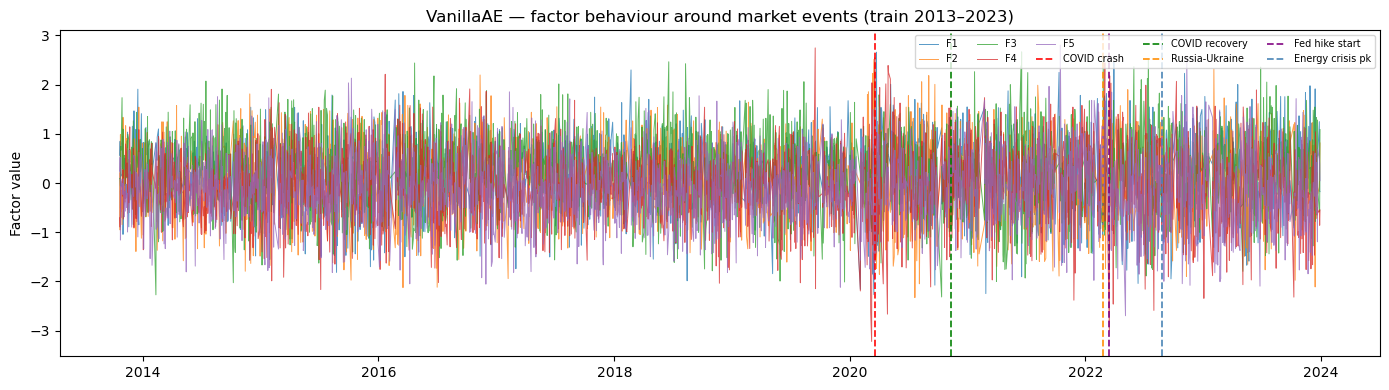

In [34]:
MARKET_EVENTS = {
    'COVID crash':      (pd.Timestamp('2020-03-20'), 'red'),
    'COVID recovery':   (pd.Timestamp('2020-11-09'), 'green'),
    'Russia-Ukraine':   (pd.Timestamp('2022-02-24'), 'darkorange'),
    'Fed hike start':   (pd.Timestamp('2022-03-16'), 'purple'),
    'Energy crisis pk': (pd.Timestamp('2022-08-26'), 'steelblue'),
}

fig, ax = plt.subplots(figsize=(14, 4))
for col in train_factors.columns:
    ax.plot(train_factors.index, train_factors[col], lw=0.7, alpha=0.75, label=col)
for ev_name, (ev_date, ev_col) in MARKET_EVENTS.items():
    if train_factors.index.min() <= ev_date <= train_factors.index.max():
        ax.axvline(ev_date, color=ev_col, lw=1.3, ls='--', alpha=0.9, label=ev_name)
ax.set_title('VanillaAE — factor behaviour around market events (train 2013–2023)')
ax.set_ylabel('Factor value')
ax.legend(loc='upper right', fontsize=7, ncol=5)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.tight_layout()
plt.show()

## 9. Factor ~ Macro Variable Regressions (One-on-One)

Simple OLS of each latent factor on each macro variable independently:

> `factor_k_t = α + β · macro_var_t + ε_t`

R² measures how much variance in the factor is explained by a single macro variable. `*` marks p < 0.05. Monthly/quarterly series are forward-filled to daily frequency before matching.

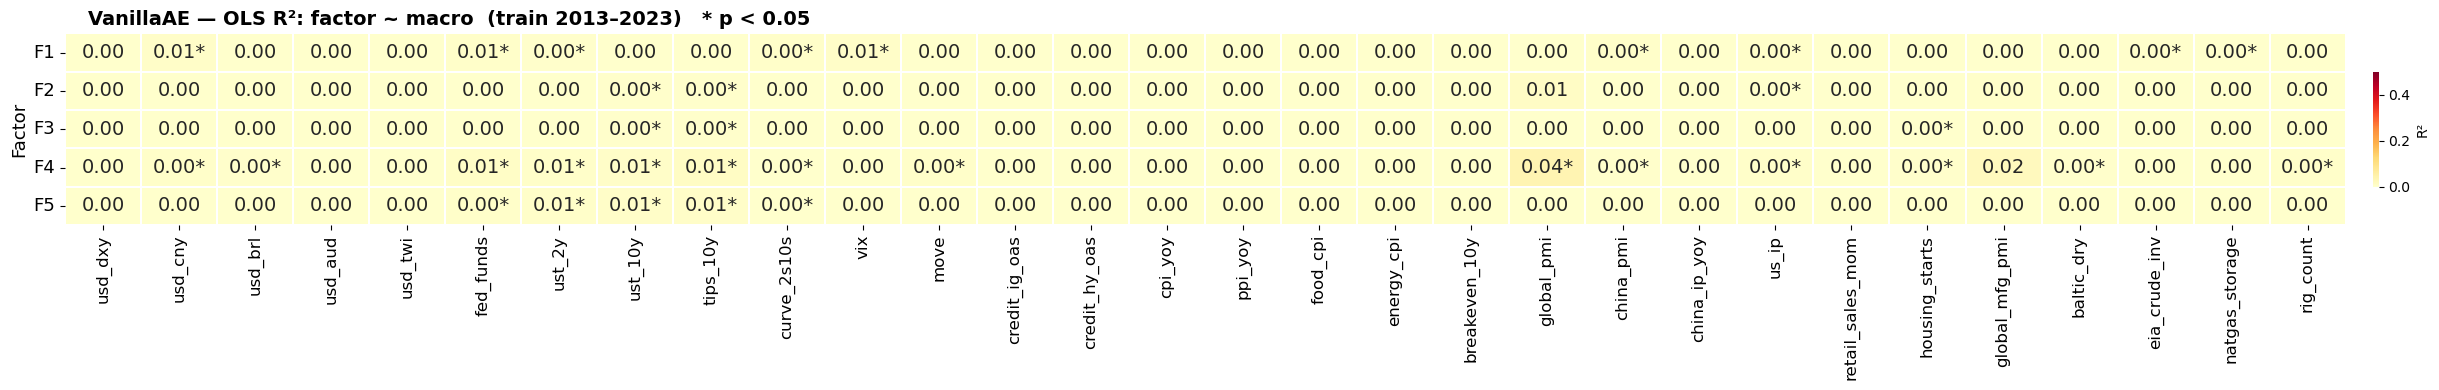

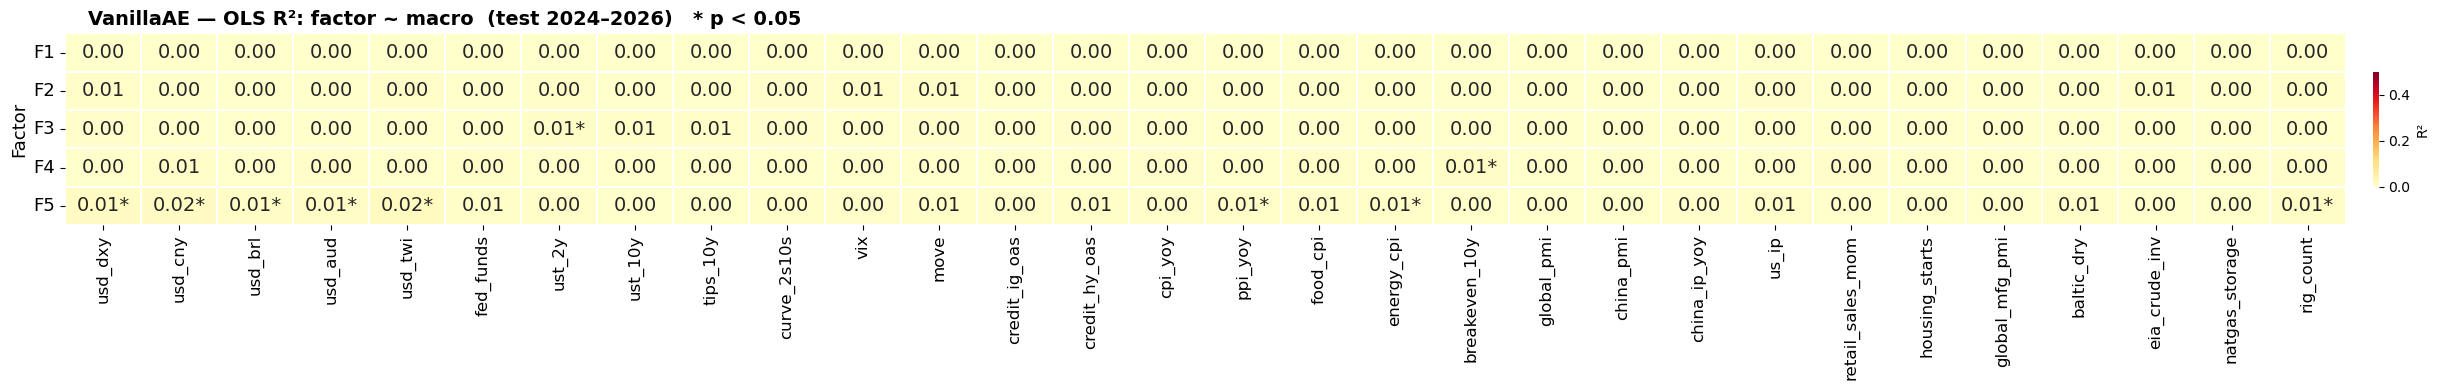


Significant macro predictors per factor  (train, p < 0.05, ranked by R²)
─────────────────────────────────────────────────────────────────

F1:
  vix                     R²=0.007  p=0.0001*
  usd_cny                 R²=0.006  p=0.0001*
  fed_funds               R²=0.005  p=0.0006*
  us_ip                   R²=0.005  p=0.0008*
  china_pmi               R²=0.005  p=0.0010*
  curve_2s10s             R²=0.004  p=0.0025*
  eia_crude_inv           R²=0.003  p=0.0061*
  ust_2y                  R²=0.002  p=0.0252*
  natgas_storage          R²=0.002  p=0.0475*

F2:
  ust_10y                 R²=0.002  p=0.0229*
  tips_10y                R²=0.002  p=0.0263*
  us_ip                   R²=0.002  p=0.0462*

F3:
  ust_10y                 R²=0.002  p=0.0227*
  tips_10y                R²=0.002  p=0.0266*
  housing_starts          R²=0.002  p=0.0442*

F4:
  global_pmi              R²=0.038  p=0.0336*
  tips_10y                R²=0.013  p=0.0000*
  fed_funds               R²=0.009  p=0.0000*
  ust_10y   

In [35]:
from scipy.stats import linregress

macro_raw   = pd.read_csv('../data/macro/macro_panel_raw.csv', index_col=0, parse_dates=True)
macro_ffill = macro_raw.ffill()

_EXCL      = {'wti', 'brent', 'natgas'}
MACRO_COLS = [c for c in macro_ffill.columns if c not in _EXCL]

def _factor_macro_r2(factors):
    common = factors.index.intersection(macro_ffill.index)
    fac    = factors.loc[common]
    mac    = macro_ffill.loc[common, MACRO_COLS]
    r2_mat = pd.DataFrame(index=fac.columns, columns=MACRO_COLS, dtype=float)
    pv_mat = pd.DataFrame(index=fac.columns, columns=MACRO_COLS, dtype=float)
    for factor in fac.columns:
        for col in MACRO_COLS:
            valid = fac[factor].notna() & mac[col].notna()
            if valid.sum() < 30:
                r2_mat.loc[factor, col] = np.nan
                pv_mat.loc[factor, col] = np.nan
                continue
            _, _, r, p, _ = linregress(mac.loc[valid, col], fac.loc[valid, factor])
            r2_mat.loc[factor, col] = r ** 2
            pv_mat.loc[factor, col] = p
    return r2_mat.astype(float), pv_mat.astype(float)

def _sig_star(p):
    if np.isnan(p): return ''
    return '*' if p < 0.05 else ''

for split, fac in [('train', train_factors), ('test', test_factors)]:
    r2, pv = _factor_macro_r2(fac)
    annot  = r2.copy().astype(object)
    for f in r2.index:
        for col in r2.columns:
            v = r2.loc[f, col]
            annot.loc[f, col] = f'{v:.2f}{_sig_star(pv.loc[f, col])}' if not np.isnan(v) else ''
    year = '2013–2023' if split == 'train' else '2024–2026'
    fig, ax = plt.subplots(figsize=(28, 4))
    sns.heatmap(
        r2, ax=ax, cmap='YlOrRd', vmin=0, vmax=0.5,
        annot=annot, fmt='', annot_kws={'size': 14},
        cbar_kws={'label': 'R²', 'shrink': 0.6, 'pad': 0.01},
        linewidths=0.3, linecolor='white',
    )
    ax.set_title(
        f'VanillaAE — OLS R²: factor ~ macro  ({split} {year})   * p < 0.05',
        fontsize=14, fontweight='bold', loc='left', x=0.01,
    )
    ax.set_ylabel('Factor', fontsize=13)
    ax.tick_params(axis='x', rotation=90, labelsize=12)
    ax.tick_params(axis='y', rotation=0,  labelsize=13)
    fig.tight_layout()
    plt.show()

r2_tr, pv_tr = _factor_macro_r2(train_factors)
print('\nSignificant macro predictors per factor  (train, p < 0.05, ranked by R²)')
print('─' * 65)
for factor in r2_tr.index:
    sig = pv_tr.loc[factor].dropna()
    sig = sig[sig < 0.05]
    if sig.empty:
        print(f'\n{factor}:  — none —')
        continue
    ranked = r2_tr.loc[factor, sig.index].sort_values(ascending=False)
    print(f'\n{factor}:')
    for col in ranked.index:
        print(f'  {col:<22}  R²={r2_tr.loc[factor, col]:.3f}  p={pv_tr.loc[factor, col]:.4f}*')

## 10. Factor Regression Formulas (Factor ~ Commodity Returns)

Multivariate OLS of each latent factor on all commodity returns:

> `factor_k = α + β₁·C₁ + β₂·C₂ + ... + β₂₇·C₂₇ + ε`

Only coefficients with p < 0.05 are retained. R² tells us how much of each factor is explained by commodity returns.

VanillaAE — factor regression formulas on commodity returns (train, p < 0.05)

F1 = +0.171  +0.036·WTI  +0.045·NaturalGas  +0.049·Diesel  -0.025·HeatingOil  +0.142·Methanol  +0.154·Gold  +0.191·Silver  +0.083·Copper  +0.056·Aluminium  +0.094·Nickel  +0.069·Zinc  +0.125·Platinum  +0.087·HRCSteel  -0.077·SGXIronOre  -0.211·Lithium  +0.029·Coffee  -0.009·Corn  +0.062·Cotton  +0.023·LeanHogs  +0.156·LiveCattle  -0.080·Sugar  +0.066·Soybeans  +0.011·SoybeanOil  -0.046·HRWWheat
  → R²=0.955  adj-R²=0.954  significant predictors: 24

F2 = +0.038  -0.091·Brent  -0.019·WTI  -0.078·Gasoline  -0.030·Diesel  -0.106·HeatingOil  -0.016·ThermalCoal  +0.108·Methanol  -0.242·Gold  -0.222·Silver  -0.048·Copper  -0.010·Aluminium  +0.013·Nickel  +0.017·Zinc  -0.197·Platinum  +0.055·HRCSteel  -0.087·SGXIronOre  -0.105·Lithium  -0.066·Coffee  +0.092·Corn  +0.126·Cotton  +0.024·LeanHogs  +0.134·LiveCattle  -0.053·Sugar  +0.182·Soybeans  +0.060·SoybeanOil  +0.092·HRWWheat
  → R²=0.942  adj-R²=0.942  significa

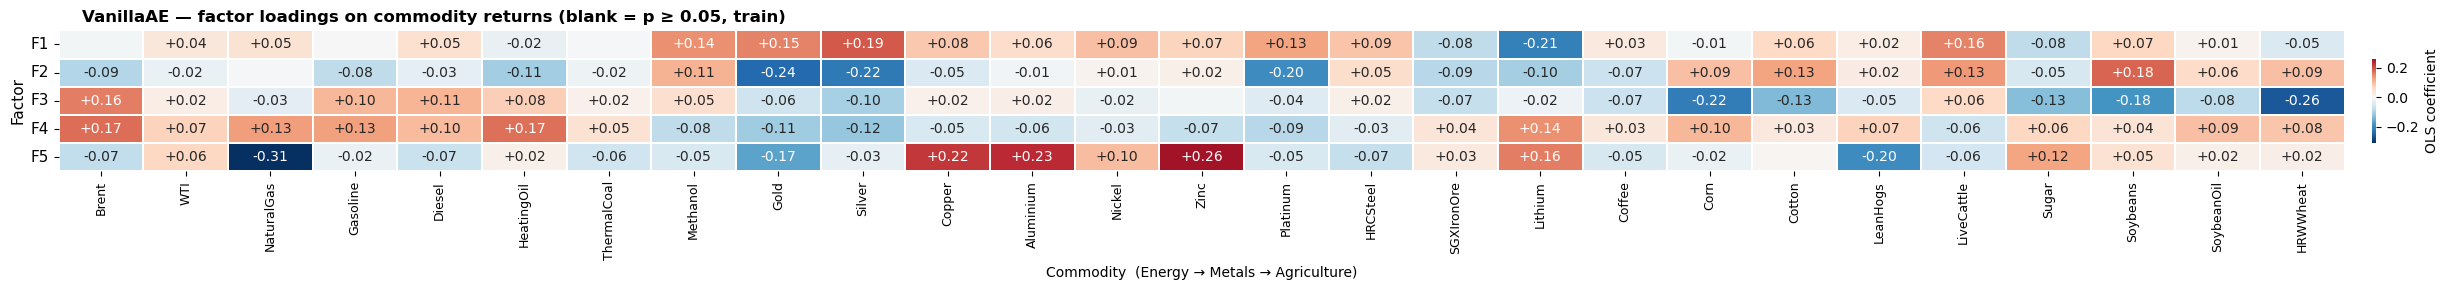

In [36]:
import statsmodels.api as sm

def _factor_ols(factors):
    rets   = returns_raw.reindex(factors.index)[COMMODITIES_ORDERED].dropna(how='all')
    common = factors.index.intersection(rets.index)
    Y = factors.loc[common]
    X = sm.add_constant(rets.loc[common])
    results = {}
    for factor in Y.columns:
        y     = Y[factor]
        valid = X.notna().all(axis=1) & y.notna()
        results[factor] = sm.OLS(y[valid], X[valid]).fit()
    return results

def _format_formula(factor, res, pval_thresh=0.05):
    params = res.params
    pvals  = res.pvalues
    sig    = pvals[pvals < pval_thresh].index.tolist()
    terms  = []
    _c = 'const'
    if _c in sig:
        terms.append(f'{params[_c]:+.3f}')
    for col in [c for c in sig if c != _c]:
        terms.append(f'{params[col]:+.3f}·{col}')
    formula = f'{factor} = ' + ('  '.join(terms) if terms else '[no significant predictors]')
    n_sig   = len([c for c in sig if c != _c])
    return formula, res.rsquared, res.rsquared_adj, n_sig

res_dict = _factor_ols(train_factors)
print('VanillaAE — factor regression formulas on commodity returns (train, p < 0.05)\n')
for factor, res in res_dict.items():
    formula, r2, adj_r2, n_sig = _format_formula(factor, res)
    print(formula)
    print(f'  → R²={r2:.3f}  adj-R²={adj_r2:.3f}  significant predictors: {n_sig}\n')

coef_df = pd.DataFrame(
    {f: res.params.drop('const') for f, res in res_dict.items()},
    index=COMMODITIES_ORDERED,
).T
pval_df = pd.DataFrame(
    {f: res.pvalues.drop('const') for f, res in res_dict.items()},
    index=COMMODITIES_ORDERED,
).T
annot = coef_df.copy().astype(object)
for f in coef_df.index:
    for col in coef_df.columns:
        v = coef_df.loc[f, col]
        p = pval_df.loc[f, col]
        annot.loc[f, col] = f'{v:+.2f}' if p < 0.05 else ''

fig, ax = plt.subplots(figsize=(28, 3))
sns.heatmap(
    coef_df, ax=ax, cmap='RdBu_r', center=0,
    annot=annot, fmt='', annot_kws={'size': 10},
    cbar_kws={'label': 'OLS coefficient', 'shrink': 0.6, 'pad': 0.01},
    linewidths=0.3, linecolor='white',
)
ax.set_title(
    'VanillaAE — factor loadings on commodity returns (blank = p ≥ 0.05, train)',
    fontsize=12, fontweight='bold', loc='left', x=0.01,
)
ax.set_xlabel('Commodity  (Energy → Metals → Agriculture)', fontsize=10)
ax.set_ylabel('Factor', fontsize=11)
ax.tick_params(axis='x', rotation=90, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=11)
fig.tight_layout()
plt.show()